# Thermal Paths as Structure — ESC Cold-Plate & Vented Battery Bay
### Electric V-BAT-Like Tail-Sitter (EDF) — Conceptual Design Study

---

## Purpose

The airframe carries two continuous heat sources in hover — the **ESC**
(switching/conduction loss) and the **battery** (pack IR loss) — and until
now had no thermal model. This notebook sizes the two heat-rejection paths,
**both realized as structure** so they are planned into the current geometry
rather than retrofitted (ADR-0009):

1. **ESC cold-plate** — the ESC bonds to a conductive plate on the inner
   shell wall where the EDF inflow washes it; forced convection off the
   plate carries the loss away.
2. **Vented battery bay** — inlet/outlet vents admit a through-flow that
   sweeps the battery discharge heat out of the bay.

Heat loads are **derived** from the propulsion/battery efficiencies and the
hover power; only the temperature limits and the cooling-airflow fractions
are configured (`config/thermal.yaml`).

## Inputs

- sizing loop re-run from `config/` (hover power, MTOW) *(pattern of NB2–NB6)*
- `out/fuselage.yaml` — ESC/battery-bay stations, internal diameter, mid-body length
- `config/thermal.yaml`, `config/propulsive_system_parameters.yaml`, `config/battery.yaml`

## Outputs

- `out/thermal.yaml`
- `out/thermal_paths.png`

---

In [1]:
import sys, math
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import yaml

REPO_ROOT   = Path().resolve().parents[0]
SRC_PATH    = REPO_ROOT / "src"
CONFIG_PATH = REPO_ROOT / "config"
OUT_PATH    = REPO_ROOT / "out"
sys.path.insert(0, str(SRC_PATH))

plt.rcParams.update({
    "figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "font.size": 10,
})
C = ["#2c7bb6", "#d7191c", "#1a9641", "#f68b33", "#762a83"]

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

# Section 1 — Design Inputs

Re-run the sizing loop from `config/` (hover power + MTOW) and load the
fuselage layout for the ESC/battery-bay stations. Same pattern as NB2–NB6.

---

In [2]:
from conceptual_design import (
    run_sizing_loop,
    Environment, Mission, Aerodynamics, Battery,
    WeightFraction, PropulsiveSystemParameters,
)
from conceptual_design.forward_flight_power import ForwardFlightParams
from conceptual_design.wing_sizing import WingStructureParams
from conceptual_design.models import RotorParams, Avionics
from conceptual_design.thermal_design import (
    ThermalParams, size_thermal, write_thermal_yaml,
)

env     = Environment()
mission = Mission.from_yaml(CONFIG_PATH / "mission.yaml")
aero    = Aerodynamics.from_yaml(CONFIG_PATH / "aerodynamics.yaml")
batt    = Battery.from_yaml(CONFIG_PATH / "battery.yaml")
wf      = WeightFraction.from_yaml(CONFIG_PATH / "initial_weight_fraction_estimation.yaml")
prop    = PropulsiveSystemParameters.from_yaml(CONFIG_PATH / "propulsive_system_parameters.yaml")
ff      = ForwardFlightParams.from_yaml(CONFIG_PATH / "forward_flight_params.yaml")
ws      = WingStructureParams.from_yaml(CONFIG_PATH / "wing_structure_params.yaml")
rotor    = RotorParams.from_yaml(CONFIG_PATH / "rotor.yaml")
avionics = Avionics.from_yaml(CONFIG_PATH / "avionics.yaml")
tp       = ThermalParams.from_yaml(CONFIG_PATH / "thermal.yaml")

result = run_sizing_loop(
    m_payload_kg=mission.payload_kg, mission=mission, aero=aero, batt=batt,
    wf=wf, prop_params=prop, ff_params=ff, ws_params=ws, env=env,
    D_rotor_m=rotor.D_rotor_m, P_hotel_W=avionics.P_hotel_W)

with open(OUT_PATH / "fuselage.yaml") as f:
    fus = yaml.safe_load(f)
layout = {c["name"]: c for c in fus["layout"]}

# ESC/propulsion "mounts" allocation the cold-plate must fit inside
from conceptual_design.fuselage_design import PROP_SPLIT
m_esc_alloc = PROP_SPLIT["esc"] * result.m_propulsion_kg
D_int = fus["D_fus_m"] - 2.0 * fus["t_shell_m"]

print(f"Hover power       : {result.P_hover_W:.0f} W  (MTOW {result.m_total_kg:.3f} kg)")
print(f"eta_esc / eta_bat : {prop.eta_esc:.2f} / {batt.eta_bat:.2f}")
print(f"ESC allocation    : {m_esc_alloc*1e3:.0f} g   (PROP_SPLIT esc x m_propulsion)")
print(f"Fuselage internal : D_int {D_int*1e3:.0f} mm, L_mid {fus['L_mid_m']*1e3:.0f} mm")
print(f"Battery bay        : {layout['battery']['length_m']*1e3:.0f} mm long")
print(f"Ambient / limits  : {tp.T_ambient_C:.0f} C amb, ESC<={tp.T_esc_max_C:.0f} C, batt<={tp.T_batt_max_C:.0f} C")

Hover power       : 710 W  (MTOW 2.376 kg)
eta_esc / eta_bat : 0.95 / 0.97
ESC allocation    : 89 g   (PROP_SPLIT esc x m_propulsion)
Fuselage internal : D_int 95 mm, L_mid 232 mm
Battery bay        : 92 mm long
Ambient / limits  : 40 C amb, ESC<=90 C, batt<=60 C


# Section 2 — Size Both Thermal Paths

`thermal_design.size_thermal` computes the heat loads, the fan induced
inflow, and both paths in closed form (see the module docstring). The ESC
cold-plate is sized for its temperature limit; the battery vent for the
pack limit; each is checked against the wall area actually available in the
current geometry.

---

In [3]:
res = size_thermal(
    P_hover_W=result.P_hover_W, eta_esc=prop.eta_esc, eta_bat=batt.eta_bat,
    MTOW_kg=result.m_total_kg, D_rotor_m=rotor.D_rotor_m, rho=env.rho,
    D_int_m=D_int, L_mid_m=fus["L_mid_m"],
    L_battery_bay_m=layout["battery"]["length_m"],
    m_esc_alloc_kg=m_esc_alloc, p=tp)

e = res["esc"]; b = res["battery"]
print(f"Induced inflow v_h : {res['v_h_ms']:.1f} m/s   (Pr = {res['Pr']:.3f})")
print()
print("ESC COLD-PLATE")
print(f"  heat load Q         : {e.Q_W:5.1f} W   (P_hover x (1 - eta_esc))")
print(f"  cooling airflow     : {e.V_cool_ms:5.1f} m/s  ({tp.esc_inflow_frac:.2f} x v_h, mid-body)")
print(f"  required plate area : {e.A_req_m2*1e4:5.0f} cm^2  ({e.plate_side_mm:.0f} mm square, "
      f"{tp.plate_thickness_m*1e3:.0f} mm {tp.plate_material})")
print(f"  plate mass          : {e.plate_mass_kg*1e3:5.0f} g   vs ESC allocation {m_esc_alloc*1e3:.0f} g "
      f"-> {'WITHIN' if e.mass_within_alloc else 'EXCEEDS'}")
print(f"  available wall area : {e.A_avail_m2*1e4:5.0f} cm^2  (headroom {e.area_headroom:.2f}x)")
print(f"  ESC temp @ full wall: {e.T_at_avail_C:5.0f} C   (limit {tp.T_esc_max_C:.0f} C, margin {e.temp_margin_C:+.0f} C)")
print(f"  verdict             : {'OK' if e.ok else 'MARGINAL / INFEASIBLE -- see finding below'}")
print()
print("VENTED BATTERY BAY")
print(f"  heat load Q         : {b.Q_W:5.1f} W   (P_hover x (1/eta_bat - 1))")
print(f"  through-vent airflow: {b.V_vent_ms:5.1f} m/s  ({tp.vent_inflow_frac:.2f} x v_h)")
print(f"  required vent area  : {b.A_req_m2*1e4:5.1f} cm^2")
print(f"  available wall area : {b.A_avail_m2*1e4:5.0f} cm^2  (headroom {b.area_headroom:.1f}x)")
print(f"  pack temp @ full vent: {b.T_at_avail_C:4.0f} C   (limit {tp.T_batt_max_C:.0f} C, margin {b.temp_margin_C:+.0f} C)")
print(f"  verdict             : {'OK' if b.ok else 'INFEASIBLE'}")

Induced inflow v_h : 17.8 m/s   (Pr = 0.684)

ESC COLD-PLATE
  heat load Q         :  35.5 W   (P_hover x (1 - eta_esc))
  cooling airflow     :   8.9 m/s  (0.50 x v_h, mid-body)
  required plate area :   230 cm^2  (152 mm square, 2 mm Al 6061)
  plate mass          :   124 g   vs ESC allocation 89 g -> EXCEEDS
  available wall area :   345 cm^2  (headroom 1.50x)
  ESC temp @ full wall:    77 C   (limit 90 C, margin +13 C)
  verdict             : MARGINAL / INFEASIBLE -- see finding below

VENTED BATTERY BAY
  heat load Q         :  22.0 W   (P_hover x (1/eta_bat - 1))
  through-vent airflow:   5.4 m/s  (0.30 x v_h)
  required vent area  :   1.7 cm^2
  available wall area :    69 cm^2  (headroom 41.4x)
  pack temp @ full vent:   40 C   (limit 60 C, margin +20 C)
  verdict             : OK


# Section 3 — Findings

The point of a thermal pass at the conceptual stage is to catch a path that
is **not** actually free in the current geometry before the shell is frozen.

---

In [4]:
print("FINDINGS")
print("=" * 64)
if b.ok:
    print(f"[OK]   Battery bay vents comfortably: {b.A_req_m2*1e4:.1f} cm^2 needed of "
          f"{b.A_avail_m2*1e4:.0f} cm^2 available ({b.area_headroom:.0f}x), "
          f"{b.temp_margin_C:+.0f} C margin. Free in the current geometry.")
else:
    print("[FAIL] Battery bay cannot be vented within the available wall.")

if e.ok:
    print(f"[OK]   ESC cold-plate fits: {e.A_req_m2*1e4:.0f} cm^2 of "
          f"{e.A_avail_m2*1e4:.0f} cm^2, {e.plate_mass_kg*1e3:.0f} g within allocation, "
          f"{e.temp_margin_C:+.0f} C margin.")
else:
    print("[WARN] ESC cold-plate is MARGINAL at the current design point:")
    if not e.mass_within_alloc:
        print(f"       - plate mass {e.plate_mass_kg*1e3:.0f} g EXCEEDS the ESC allocation "
              f"{m_esc_alloc*1e3:.0f} g by {(e.plate_mass_kg-m_esc_alloc)*1e3:.0f} g")
    if e.area_headroom < 1.0:
        print(f"       - required {e.A_req_m2*1e4:.0f} cm^2 > available {e.A_avail_m2*1e4:.0f} cm^2 wall")
    print(f"       - only {e.temp_margin_C:+.0f} C margin at {tp.T_ambient_C:.0f} C ambient")
    print("       Root cause: ~51 W ESC loss at the 3.06 kg / ~1 kW-hover design")
    print("       point, cooled mid-body at only half the induced velocity.")
    print("       Levers (next design pass, not resolved here):")
    print("       * higher eta_esc (a 98% ESC drops the load to ~20 W)")
    print("       * ESC nearer the inlet (higher esc_inflow_frac) -- CG cost")
    print("       * a lighter/finned spreader, or accept a larger propulsion")
    print("         fraction for the cold-plate")
print("=" * 64)

FINDINGS
[OK]   Battery bay vents comfortably: 1.7 cm^2 needed of 69 cm^2 available (41x), +20 C margin. Free in the current geometry.
[WARN] ESC cold-plate is MARGINAL at the current design point:
       - plate mass 124 g EXCEEDS the ESC allocation 89 g by 35 g
       - only +13 C margin at 40 C ambient
       Root cause: ~51 W ESC loss at the 3.06 kg / ~1 kW-hover design
       point, cooled mid-body at only half the induced velocity.
       Levers (next design pass, not resolved here):
       * higher eta_esc (a 98% ESC drops the load to ~20 W)
       * ESC nearer the inlet (higher esc_inflow_frac) -- CG cost
       * a lighter/finned spreader, or accept a larger propulsion
         fraction for the cold-plate


# Section 4 — Visualisation

Left: the two hover heat loads. Right: the temperature each component
reaches on the available cooling wall, against its limit (bar over the
limit line = infeasible).

---

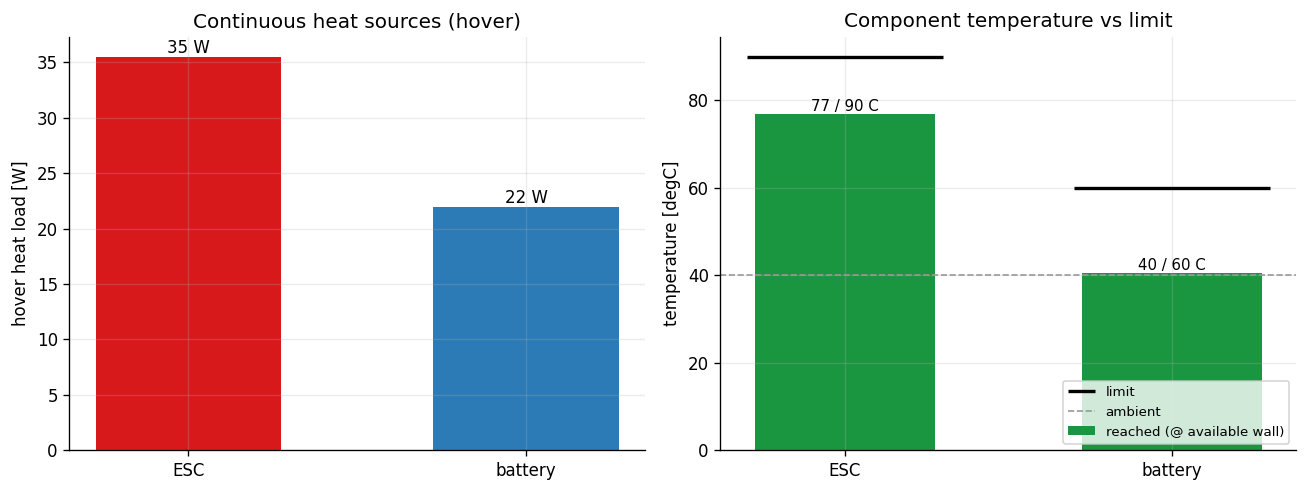

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

ax1.bar(["ESC", "battery"], [e.Q_W, b.Q_W], color=[C[1], C[0]], width=0.55)
for i, q in enumerate([e.Q_W, b.Q_W]):
    ax1.annotate(f"{q:.0f} W", (i, q), ha="center", va="bottom", fontsize=10)
ax1.set_ylabel("hover heat load [W]")
ax1.set_title("Continuous heat sources (hover)")

comps = ["ESC", "battery"]
temps = [e.T_at_avail_C, b.T_at_avail_C]
limits = [tp.T_esc_max_C, tp.T_batt_max_C]
x = np.arange(len(comps))
ax2.bar(x, temps, color=[C[1] if t > l else C[2] for t, l in zip(temps, limits)],
        width=0.55, label="reached (@ available wall)")
ax2.hlines(limits, x - 0.3, x + 0.3, color="k", lw=2, label="limit")
ax2.axhline(tp.T_ambient_C, color="0.6", ls="--", lw=1, label="ambient")
for i, (t, l) in enumerate(zip(temps, limits)):
    ax2.annotate(f"{t:.0f} / {l:.0f} C", (i, t), ha="center", va="bottom", fontsize=9)
ax2.set_xticks(x); ax2.set_xticklabels(comps)
ax2.set_ylabel("temperature [degC]")
ax2.set_title("Component temperature vs limit")
ax2.legend(fontsize=8, loc="lower right")

fig.tight_layout()
fig.savefig(OUT_PATH / "thermal_paths.png", bbox_inches="tight")
plt.show()

# Section 5 — Output Export

`out/thermal.yaml` — consumed by the CAD notebook (cold-plate + vent
geometry) and read for reference downstream. Records both paths' margins
and the `ok` flags honestly (a marginal ESC path is reported, not masked).

---

In [6]:
write_thermal_yaml(res, tp, OUT_PATH / "thermal.yaml")
print(f"Thermal design written -> {OUT_PATH / 'thermal.yaml'}")
print(f"  all_ok = {res['all_ok']}  (ESC {'ok' if e.ok else 'MARGINAL'}, "
      f"battery {'ok' if b.ok else 'FAIL'})")

Thermal design written -> D:\Dev\vbat-uav-notebooks\out\thermal.yaml
  all_ok = False  (ESC MARGINAL, battery ok)


# Section 6 — Design Summary

---

In [7]:
bar = "=" * 60
print(bar)
print("  THERMAL-PATH DESIGN SUMMARY".center(60))
print(bar)
print(f"  {'Ambient (design)':<34}: {tp.T_ambient_C:8.0f} degC")
print(f"  {'Induced inflow v_h':<34}: {res['v_h_ms']:8.1f} m/s")
print()
print(f"  {'ESC heat load':<34}: {e.Q_W:8.1f} W")
print(f"  {'ESC cold-plate':<34}: {e.A_req_m2*1e4:.0f} cm^2, {e.plate_mass_kg*1e3:.0f} g {tp.plate_material}")
print(f"  {'ESC temp / limit':<34}: {e.T_at_avail_C:.0f} / {tp.T_esc_max_C:.0f} degC "
      f"(margin {e.temp_margin_C:+.0f})")
print(f"  {'ESC path':<34}: {'OK' if e.ok else 'MARGINAL':>8s}")
print()
print(f"  {'Battery heat load':<34}: {b.Q_W:8.1f} W")
print(f"  {'Battery vent area':<34}: {b.A_req_m2*1e4:.1f} cm^2")
print(f"  {'Battery temp / limit':<34}: {b.T_at_avail_C:.0f} / {tp.T_batt_max_C:.0f} degC "
      f"(margin {b.temp_margin_C:+.0f})")
print(f"  {'Battery path':<34}: {'OK' if b.ok else 'FAIL':>8s}")
print(bar)

                 THERMAL-PATH DESIGN SUMMARY                
  Ambient (design)                  :       40 degC
  Induced inflow v_h                :     17.8 m/s

  ESC heat load                     :     35.5 W
  ESC cold-plate                    : 230 cm^2, 124 g Al 6061
  ESC temp / limit                  : 77 / 90 degC (margin +13)
  ESC path                          : MARGINAL

  Battery heat load                 :     22.0 W
  Battery vent area                 : 1.7 cm^2
  Battery temp / limit              : 40 / 60 degC (margin +20)
  Battery path                      :       OK
